# Figure 3 - Falsifying Simple Explanations of Plasticity Loss

Section 5.1 of the paper asks whether plasticity loss can be explained away by a single, easy-to-compute network statistic. Four candidates are tested: **weight norm**, **weight rank**, the fraction of **dead ReLU units**, and **feature rank** (the rank of the penultimate-layer representation).

The protocol: train a DQN agent on one of the three classification MDPs (`easy`, `hard`, `sparse`), and every `probe_every` optimizer steps, pause training to (a) run the random-target plasticity probe from Section 2.2 and (b) recompute all four statistics on the current network. If a statistic really explained plasticity loss, its correlation with plasticity loss should be consistently strong and same-signed across every controlled comparison (observation space, architecture, or environment). The paper's finding is that it isn't — this notebook lets you check that directly on the correlation table below.

This notebook builds the experiment inline from the shared building blocks in `src/experiments/` (DQN loop, plasticity probe, and the four statistic functions), rather than delegating to a wrapper module, so every knob is visible and editable here.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

Everything below comes from the reusable building blocks in `src/`: the shared DQN training loop (`src.experiments.dqn_classification`), the replay buffer (`src.agents.replay_buffer`), the random-target plasticity probe (`src.experiments.plasticity`), and the four candidate statistics (`weight_norm`, `weight_rank`, `dead_units`, `feature_rank`). The experiment-specific logic — how to combine them into Figure 3's train-probe-record loop — lives in this notebook.

In [ ]:
import copy
import time
from dataclasses import dataclass, replace
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from src.experiments.dead_units import compute_dead_units
from src.experiments.dqn_classification import (
    DEVICE,
    ClassificationDQNConfig,
    build_environment,
    build_model_factory,
    build_optimizer,
    collect_transition,
    epsilon_at_step,
    load_dataset,
    optimizer_factory_from_config,
    set_seed,
    train_dqn_step,
)
from src.agents.replay_buffer import ReplayBuffer
from src.experiments.feature_rank import compute_model_feature_rank
from src.experiments.plasticity import PlasticityProbeConfig, estimate_probe_loss
from src.experiments.weight_norm import compute_weight_norm
from src.experiments.weight_rank import compute_weight_rank

DEVICE

## Run Configuration

`Figure3RunConfig` extends the shared DQN config with the extra knobs this experiment needs: how often to pause and probe (`probe_every`), and the probe's own step/task/batch-size budget. `FIGURE3_SCHEMA` fixes the column order of the summary table produced below.

In [3]:
@dataclass
class Figure3RunConfig(ClassificationDQNConfig):
    probe_every: int = 5_000
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512
    metric_batch_size: int = 512


FIGURE3_SCHEMA = [
    "run_id",
    "seed",
    "observation_space",
    "environment",
    "architecture",
    "optimizer",
    "step",
    "probe_loss",
    "initial_probe_loss",
    "plasticity_loss",
    "weight_norm",
    "weight_rank",
    "dead_units",
    "feature_rank",
]

## Panel Definitions

Figure 3 renders one scatter panel per statistic. Each panel holds one variable fixed (e.g. weight-norm's panel compares `mnist` vs. `cifar10` while everything else is held at its default) so a real explanatory statistic would have to show a consistent correlation *within* every condition, not just on average.

In [4]:
@dataclass(frozen=True)
class PanelSpec:
    panel: str
    title: str
    x_column: str
    x_label: str
    condition_column: str
    conditions: Tuple[str, ...]


PANEL_SPECS: Tuple[PanelSpec, ...] = (
    PanelSpec(
        panel="weight_norm",
        title="Varying observation space",
        x_column="weight_norm",
        x_label="Weight norm",
        condition_column="observation_space",
        conditions=("cifar10", "mnist"),
    ),
    PanelSpec(
        panel="weight_rank",
        title="Varying observation space",
        x_column="weight_rank",
        x_label="Weight rank",
        condition_column="observation_space",
        conditions=("cifar10", "mnist"),
    ),
    PanelSpec(
        panel="dead_units",
        title="Varying architecture",
        x_column="dead_units",
        x_label="Dead units",
        condition_column="architecture",
        conditions=("cnn", "mlp"),
    ),
    PanelSpec(
        panel="feature_rank",
        title="Varying reward function",
        x_column="feature_rank",
        x_label="Feature rank",
        condition_column="environment",
        conditions=("easy", "hard", "sparse"),
    ),
)

COLORS = {
    "cifar10": "#23c4b6",
    "mnist": "#6d3df2",
    "cnn": "#23c4b6",
    "mlp": "#6d3df2",
    "easy": "#23c4b6",
    "hard": "#6d3df2",
    "sparse": "#e83f76",
}


def _has_regression_support(x: np.ndarray, y: np.ndarray) -> bool:
    return len(x) >= 2 and float(np.std(x)) > 1e-12 and float(np.std(y)) > 1e-12

## Training + Probing Loop

`run_training_config` runs the shared DQN loop step by step (rather than calling `run_dqn_training` end-to-end) because it needs to interleave plasticity probing and statistic computation every `probe_every` steps. `metric_row` is the per-checkpoint measurement: it samples a probe batch from the replay buffer, runs the random-target probe, and recomputes all four candidate statistics on the same batch.

In [ ]:
def run_id_for(config: Figure3RunConfig) -> str:
    return (
        f"{config.observation_space}_{config.environment}_"
        f"{config.architecture}_{config.optimizer}_seed{config.seed}"
    )


def _mean_probe_loss(results) -> float:
    return float(np.mean([result.final_loss for result in results]))


def compute_probe_loss(
    model,
    model_factory,
    optimizer_factory,
    replay: ReplayBuffer,
    config: Figure3RunConfig,
    desc: Optional[str] = None,
) -> float:
    states = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps,
        num_tasks=config.num_probe_tasks,
        batch_size=config.probe_batch_size,
    )
    return _mean_probe_loss(
        estimate_probe_loss(
            model, model_factory, states, optimizer_factory, probe_config, desc=desc
        )
    )


def metric_row(
    run_id: str,
    config: Figure3RunConfig,
    step: int,
    model,
    model_factory,
    optimizer_factory,
    replay: ReplayBuffer,
    initial_probe_loss: float,
    probe_loss_override: Optional[float] = None,
) -> Dict[str, object]:
    metric_states = replay.sample_states(config.metric_batch_size, device=DEVICE)
    probe_loss = (
        compute_probe_loss(
            model, model_factory, optimizer_factory, replay, config,
            desc=f"probe @ step {step}",
        )
        if probe_loss_override is None
        else probe_loss_override
    )

    row = {
        "run_id": run_id,
        "seed": config.seed,
        "observation_space": config.observation_space,
        "environment": config.environment,
        "architecture": config.architecture,
        "optimizer": config.optimizer,
        "step": step,
        "probe_loss": probe_loss,
        "initial_probe_loss": initial_probe_loss,
        "plasticity_loss": probe_loss - initial_probe_loss,
        "weight_norm": compute_weight_norm(model),
        "weight_rank": compute_weight_rank(model),
        "dead_units": compute_dead_units(model, metric_states),
        "feature_rank": compute_model_feature_rank(model, metric_states),
    }
    print(
        f"    step {step:>6}: probe_loss={row['probe_loss']:.4f} "
        f"plasticity_loss={row['plasticity_loss']:+.4f} "
        f"weight_norm={row['weight_norm']:.2f} weight_rank={row['weight_rank']:.1f} "
        f"dead_units={row['dead_units']:.0f} feature_rank={row['feature_rank']}"
    )
    return row


def run_training_config(config: Figure3RunConfig) -> pd.DataFrame:
    run_id = run_id_for(config)
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_model_factory(config, input_shape)
    model = model_factory().to(DEVICE)
    target_model = copy.deepcopy(model).to(DEVICE)
    optimizer = build_optimizer(config, model)
    optimizer_factory = optimizer_factory_from_config(config)
    replay = ReplayBuffer(config.replay_capacity)

    for _ in tqdm(range(config.warmup_steps), desc="warmup", unit="step", leave=False):
        collect_transition(env, model, replay, epsilon=1.0, device=DEVICE)

    initial_probe_loss = compute_probe_loss(
        model, model_factory, optimizer_factory, replay, config, desc="initial probe"
    )

    rows = [
        metric_row(
            run_id, config, 0, model, model_factory, optimizer_factory, replay,
            initial_probe_loss, probe_loss_override=initial_probe_loss,
        )
    ]

    last_loss = float("nan")
    train_bar = tqdm(range(1, config.train_steps + 1), desc=f"train {run_id}", unit="step")
    for step in train_bar:
        epsilon = epsilon_at_step(config, step)
        collect_transition(env, model, replay, epsilon=epsilon, device=DEVICE)
        last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=DEVICE)

        if step % 100 == 0:
            train_bar.set_postfix(loss=f"{last_loss:.4f}", eps=f"{epsilon:.2f}")

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())

        if step % config.probe_every == 0:
            rows.append(
                metric_row(
                    run_id, config, step, model, model_factory, optimizer_factory,
                    replay, initial_probe_loss,
                )
            )
    train_bar.close()

    return pd.DataFrame(rows, columns=FIGURE3_SCHEMA)

## Smoke vs. Paper-Scale Configurations

`make_smoke_configs` runs a handful of tiny, fast configs so the whole pipeline (train, probe, plot) can be sanity-checked in under a minute. `make_paper_configs` reproduces the paper's sweep: every combination of MNIST/CIFAR-10 and easy/hard/sparse, at full training length, across the requested seeds — this is much slower and downloads CIFAR-10/MNIST if not already cached.

In [ ]:
def make_smoke_configs(data_root: str = "./data", download: bool = False) -> List[Figure3RunConfig]:
    base = Figure3RunConfig(
        data_root=data_root,
        download=download,
        hidden_dim=128,
        batch_size=128,
        replay_capacity=5_000,
        warmup_steps=512,
        train_steps=1_000,
        target_update_period=250,
        probe_every=500,
        probe_steps=25,
        num_probe_tasks=2,
        probe_batch_size=128,
        metric_batch_size=128,
    )
    return [
        replace(base, seed=0, observation_space="mnist", environment="easy", architecture="mlp"),
        replace(base, seed=1, observation_space="mnist", environment="hard", architecture="mlp"),
        replace(base, seed=2, observation_space="mnist", environment="sparse", architecture="mlp"),
        replace(base, seed=3, observation_space="mnist", environment="easy", architecture="cnn"),
    ]


def make_paper_configs(
    data_root: str = "./data",
    download: bool = False,
    seeds: Sequence[int] = tuple(range(4)),
) -> List[Figure3RunConfig]:
    configs: List[Figure3RunConfig] = []
    for seed in seeds:
        for observation_space in ["mnist", "cifar10"]:
            for environment in ["easy", "hard", "sparse"]:
                for architecture in ["cnn", "mlp"]:
                    configs.append(
                        Figure3RunConfig(
                            seed=seed,
                            data_root=data_root,
                            download=download,
                            observation_space=observation_space,
                            environment=environment,
                            architecture=architecture,
                            hidden_dim=512,
                            train_steps=10_000,
                            target_update_period=1_000,
                            probe_every=5_000,
                            probe_steps=2_000,
                            num_probe_tasks=10,
                            probe_batch_size=512,
                            metric_batch_size=512,
                        )
                    )
    return configs


def run_sweep(
    configs: Sequence[Figure3RunConfig],
    save_path: Optional[str] = None,
) -> pd.DataFrame:
    frames = []
    sweep_start = time.perf_counter()
    for idx, config in enumerate(configs, start=1):
        print(f"[{idx}/{len(configs)}] {run_id_for(config)}")
        config_start = time.perf_counter()
        frames.append(run_training_config(config))
        config_min = (time.perf_counter() - config_start) / 60
        elapsed_min = (time.perf_counter() - sweep_start) / 60
        remaining_min = elapsed_min / idx * (len(configs) - idx)
        print(
            f"[{idx}/{len(configs)}] done in {config_min:.1f} min | "
            f"elapsed {elapsed_min:.1f} min | est. remaining {remaining_min:.0f} min"
        )
    df = pd.concat(frames, ignore_index=True)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved summary rows to {save_path}")
    return df

## Run the Smoke Sweep

Trains all four smoke configs and records a probe/statistics row every `probe_every` steps. Swap `make_smoke_configs(...)` for `make_paper_configs(...)` below for a closer reproduction — that sweep is intentionally much heavier (24+ full training runs).

In [7]:
configs = make_smoke_configs(data_root=str(DATA_ROOT), download=False)
pd.DataFrame([c.__dict__ for c in configs])

,seed,data_root,download,observation_space,environment,architecture,hidden_dim,cnn_channels,cnn_fc_dim,gamma,...,spectral_norm,shrink_perturb_every,shrink,perturb,reset_last_layer_every,probe_every,probe_steps,num_probe_tasks,probe_batch_size,metric_batch_size
0,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
1,1,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,hard,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
2,2,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,sparse,mlp,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128
3,3,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,128,64,256,0.99,...,False,None,0.4,0.1,None,500,25,2,128,128


In [8]:
summary_path = TABLES_DIR / "figure3_falsification_summary.csv"
df = run_sweep(configs, save_path=summary_path)

df

Running config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'mlp', 'hidden_dim': 128, 'cnn_channels': 64, 'cnn_fc_dim': 256, 'gamma': 0.99, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0, 'batch_size': 128, 'replay_capacity': 5000, 'warmup_steps': 512, 'train_steps': 1000, 'target_update_period': 250, 'epsilon_start': 1.0, 'epsilon_final': 0.1, 'epsilon_decay': 10000, 'use_layernorm': False, 'spectral_norm': False, 'shrink_perturb_every': None, 'shrink': 0.4, 'perturb': 0.1, 'reset_last_layer_every': None, 'probe_every': 500, 'probe_steps': 25, 'num_probe_tasks': 2, 'probe_batch_size': 128, 'metric_batch_size': 128}
mnist_easy_mlp_adam_seed0: step=500, loss=0.0096, epsilon=0.956
mnist_easy_mlp_adam_seed0: step=1000, loss=0.0185, epsilon=0.914
Running config: {'seed': 1, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'd

,run_id,seed,observation_space,environment,architecture,optimizer,step,probe_loss,initial_probe_loss,plasticity_loss,weight_norm,weight_rank,dead_units,feature_rank
0,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,0,0.237004,0.237004,0.000000,9.452216,88.666667,9.0,119
1,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,500,0.282076,0.237004,0.045071,13.348791,88.666667,33.0,113
2,mnist_easy_mlp_adam_seed0,0,mnist,easy,mlp,adam,1000,0.285711,0.237004,0.048707,16.520708,88.666667,35.0,112
3,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,0,0.231781,0.231781,0.000000,9.449522,88.666667,6.0,122
4,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,500,0.288769,0.231781,0.056988,13.573909,88.666667,45.0,113
5,mnist_hard_mlp_adam_seed1,1,mnist,hard,mlp,adam,1000,0.260271,0.231781,0.028490,16.201235,88.666667,46.0,114
6,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,0,0.222728,0.222728,0.000000,9.397131,88.666667,11.0,117
7,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,500,0.320860,0.222728,0.098132,12.765138,88.666667,46.0,121
8,mnist_sparse_mlp_adam_seed2,2,mnist,sparse,mlp,adam,1000,0.313039,0.222728,0.090311,15.417507,88.666667,52.0,122
9,mnist_easy_cnn_adam_seed3,3,mnist,easy,cnn,adam,0,0.079850,0.079850,0.000000,14.779186,122.200000,92.0,127


## Optional: Load an Existing Summary

Re-loading a previously saved table lets you re-run the analysis/plotting cells below without repeating the (expensive) training sweep.

In [9]:
def validate_summary_table(df: pd.DataFrame) -> None:
    missing = [column for column in FIGURE3_SCHEMA if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required Figure 3 columns: {missing}")


def load_summary_table(path) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_parquet(path) if path.suffix.lower() == ".parquet" else pd.read_csv(path)
    validate_summary_table(df)
    return df


# df = load_summary_table(TABLES_DIR / "figure3_falsification_summary.csv")
# df.head()

## Correlation Checks

The paper's point is not that these statistics never correlate with plasticity loss, but that the sign and strength are not stable across interventions/tasks. `figure3_long_table` reshapes the wide summary into one row per (run, panel, step); `correlation_summary` then computes the Pearson correlation and linear-fit slope of each statistic against plasticity loss, split by the panel's controlled condition.

In [10]:
def figure3_long_table(df: pd.DataFrame) -> pd.DataFrame:
    validate_summary_table(df)
    rows = []
    for _, row in df.iterrows():
        for panel, column in [
            ("weight_norm", "weight_norm"),
            ("weight_rank", "weight_rank"),
            ("dead_units", "dead_units"),
            ("feature_rank", "feature_rank"),
        ]:
            rows.append(
                {
                    **row.to_dict(),
                    "panel": panel,
                    "statistic_name": column,
                    "statistic_value": float(row[column]),
                }
            )
    return pd.DataFrame(rows)


def correlation_summary(df: pd.DataFrame) -> pd.DataFrame:
    long_df = figure3_long_table(df)
    rows = []
    for spec in PANEL_SPECS:
        panel_df = long_df[long_df["panel"] == spec.panel]
        for condition in spec.conditions:
            group = panel_df[panel_df[spec.condition_column] == condition]
            x = group["statistic_value"].to_numpy()
            y = group["plasticity_loss"].to_numpy()
            if not _has_regression_support(x, y):
                corr, slope = np.nan, np.nan
            else:
                corr = float(np.corrcoef(x, y)[0, 1])
                slope = float(np.polyfit(x, y, 1)[0])
            rows.append(
                {
                    "panel": spec.panel,
                    "condition": condition,
                    "n": len(group),
                    "pearson_r": corr,
                    "linear_slope": slope,
                }
            )
    return pd.DataFrame(rows)

In [11]:
correlation_summary(df)

,panel,condition,n,pearson_r,linear_slope
0,weight_norm,cifar10,0,NaN,NaN
1,weight_norm,mnist,12,0.632294,0.002626
2,weight_rank,cifar10,0,NaN,NaN
3,weight_rank,mnist,12,0.179285,0.000532
4,dead_units,cnn,3,0.777854,0.000471
5,dead_units,mlp,9,0.870382,0.001804
6,feature_rank,easy,6,-0.326482,-0.002541
7,feature_rank,hard,3,-0.912211,-0.005269
8,feature_rank,sparse,3,0.965903,0.019911


## Plot Figure 3

One scatter (plus linear fit) per candidate statistic, colored by the panel's controlled condition.

In [12]:
def plot_figure3(df: pd.DataFrame, save_path=None):
    import matplotlib.pyplot as plt

    long_df = figure3_long_table(df)
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), constrained_layout=True)
    fig.suptitle("Falsification of explanations of plasticity", fontsize=13, y=1.04)

    for ax, spec in zip(axes, PANEL_SPECS):
        panel_df = long_df[long_df["panel"] == spec.panel]
        for condition in spec.conditions:
            group = panel_df[panel_df[spec.condition_column] == condition]
            if group.empty:
                continue
            color = COLORS[condition]
            ax.scatter(
                group["statistic_value"], group["plasticity_loss"],
                s=24, alpha=0.62, color=color, edgecolor="none", label=condition,
            )
            x = group["statistic_value"].to_numpy()
            y = group["plasticity_loss"].to_numpy()
            if _has_regression_support(x, y):
                slope, intercept = np.polyfit(x, y, 1)
                xs = np.linspace(float(x.min()), float(x.max()), 100)
                ax.plot(xs, slope * xs + intercept, color=color, linewidth=1.6)

        ax.set_title(spec.title, fontsize=11)
        ax.set_xlabel(spec.x_label)
        ax.grid(True, linewidth=0.6, alpha=0.55)
        ax.legend(frameon=True, fontsize=9)

    axes[0].set_ylabel("Plasticity loss")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    return fig

Saved figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figures/figure3_falsification_reproduction.png


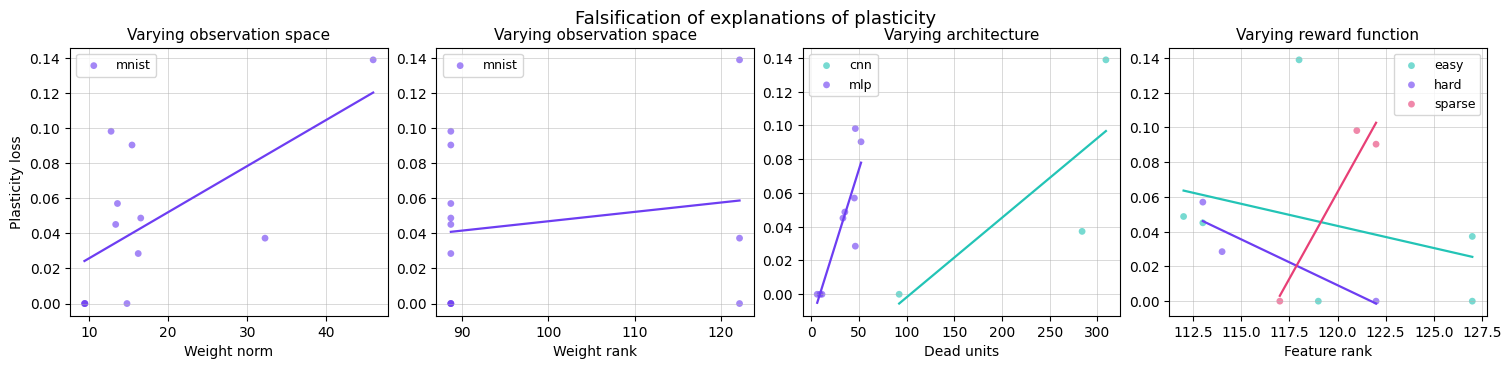

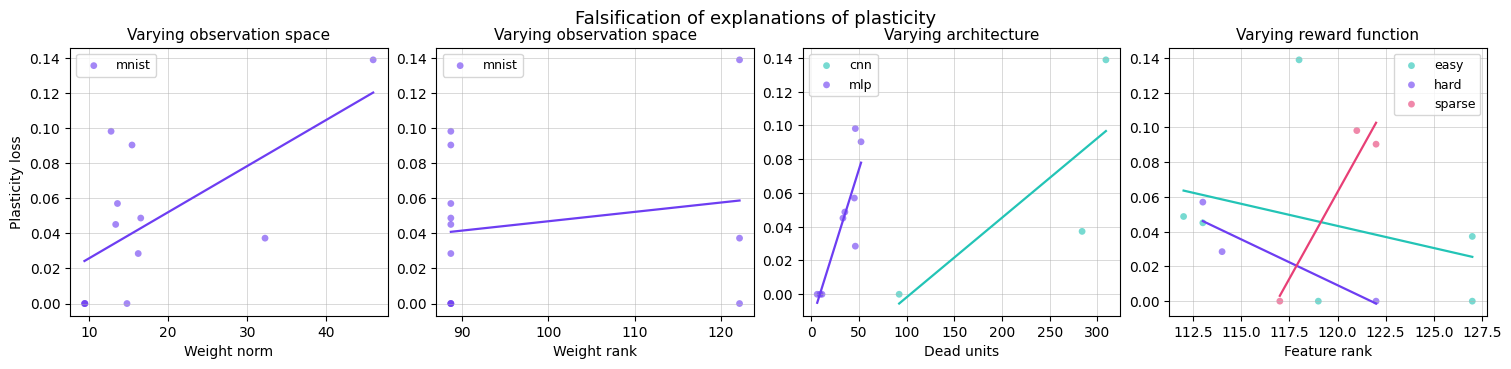

In [13]:
figure_path = FIGURES_DIR / "figure3_falsification_reproduction.png"
fig = plot_figure3(df, save_path=figure_path)
fig

## Paper-Scale Starting Point

Uncomment to run the full sweep (4 seeds x 2 observation spaces x 3 environments, 10,000 training steps each). This downloads MNIST/CIFAR-10 if not already cached and takes substantially longer than the smoke run above.

In [14]:
paper_configs = make_paper_configs(data_root=str(DATA_ROOT), download=True, seeds=[5, 40, 10, 19])
paper_df = run_sweep(paper_configs, save_path=TABLES_DIR / "figure3_falsification_summary_paper.csv")
correlation_summary(paper_df)

Running config: {'seed': 5, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': True, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'cnn', 'hidden_dim': 512, 'cnn_channels': 64, 'cnn_fc_dim': 256, 'gamma': 0.99, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0, 'batch_size': 512, 'replay_capacity': 50000, 'warmup_steps': 2000, 'train_steps': 10000, 'target_update_period': 1000, 'epsilon_start': 1.0, 'epsilon_final': 0.1, 'epsilon_decay': 10000, 'use_layernorm': False, 'spectral_norm': False, 'shrink_perturb_every': None, 'shrink': 0.4, 'perturb': 0.1, 'reset_last_layer_every': None, 'probe_every': 5000, 'probe_steps': 2000, 'num_probe_tasks': 10, 'probe_batch_size': 512, 'metric_batch_size': 512}


KeyboardInterrupt: 